<a href="https://colab.research.google.com/github/athirasivadas94-glitch/EntriAssignments/blob/main/Assignment06_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Regression Assignment Objective:**

The objective of this assignment is to evaluate your understanding of regression techniques in
supervised learning by applying them to a real-world dataset.

**Dataset:**

Use the California Housing dataset available in the sklearn library. This dataset contains information about various features of houses in California and their respective median prices.

1. Loading and Preprocessing

● Load the California Housing dataset using the fetch_california_housing function from sklearn.

● Convert the dataset into a pandas DataFrame for easier handling. Handle
missing values (if any) and perform necessary feature scaling (e.g.,
standardization).

● Explain the preprocessing steps you performed and justify why they are
necessary for this dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error,r2_score



In [ ]:
# Load the dataset
housing = fetch_california_housing()


In [ ]:
# Convert to DataFrame for easier analysis
df = pd.DataFrame(housing.data, columns=housing.feature_names)

In [ ]:
# Display the contents to make sure that data is loaded properly
df.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25


In [ ]:
#summary of your dataset structure
df.info()
#The California Housing dataset contains 20,640 records and 8 numerical features. All columns are of float data type and the dataset has no missing values, making it clean and ready for regression analysis. The dataset size is approximately 1.3 MB.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [ ]:
#statistical summary statistics for all numerical columns in the dataset.
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000


In [ ]:
#checks for missing (null) values in each column  "No null values"
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0


array([[<Axes: title={'center': 'MedInc'}>,
        <Axes: title={'center': 'HouseAge'}>,
        <Axes: title={'center': 'AveRooms'}>],
       [<Axes: title={'center': 'AveBedrms'}>,
        <Axes: title={'center': 'Population'}>,
        <Axes: title={'center': 'AveOccup'}>],
       [<Axes: title={'center': 'Latitude'}>,
        <Axes: title={'center': 'Longitude'}>, <Axes: >]], dtype=object)

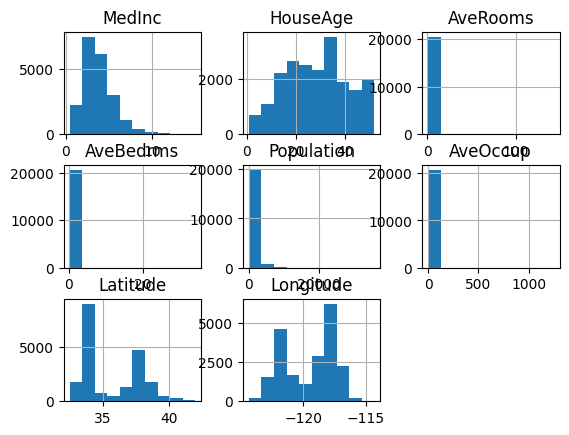

In [ ]:
df.hist()

<Axes: ylabel='MedInc'>

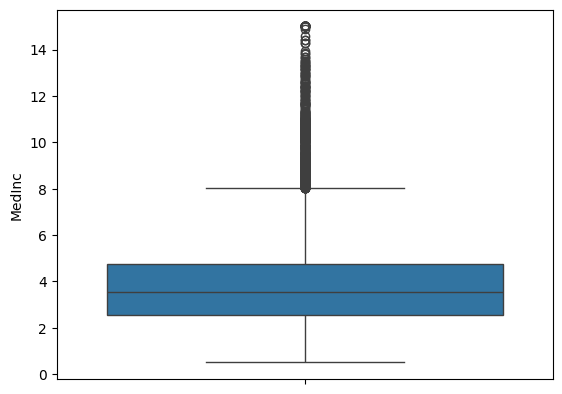

In [ ]:
sns.boxplot(data=df['MedInc'])

<Axes: ylabel='HouseAge'>

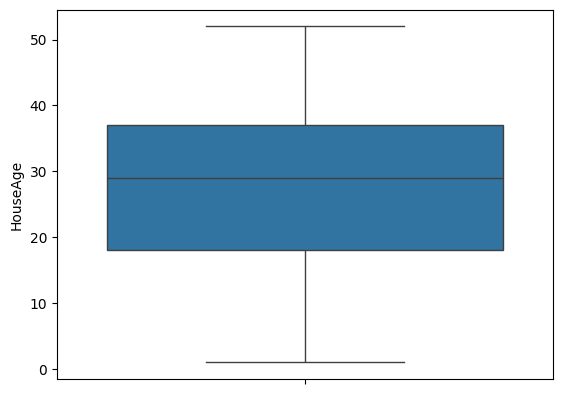

In [ ]:
sns.boxplot(data=df['HouseAge'])

<Axes: ylabel='AveRooms'>

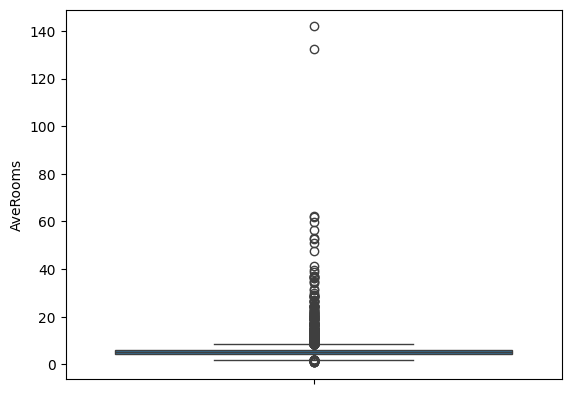

In [ ]:
sns.boxplot(data=df['AveRooms'])

<Axes: ylabel='AveBedrms'>

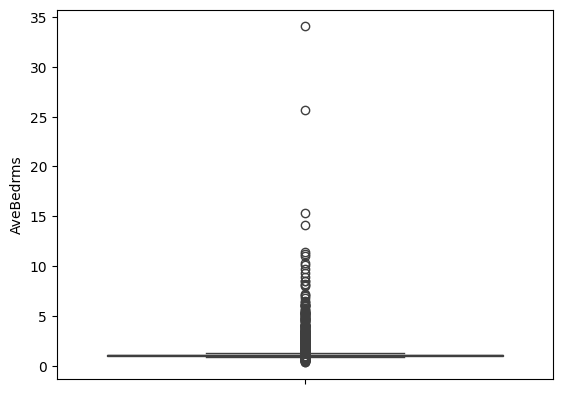

In [ ]:
sns.boxplot(data=df['AveBedrms'])

<Axes: ylabel='Population'>

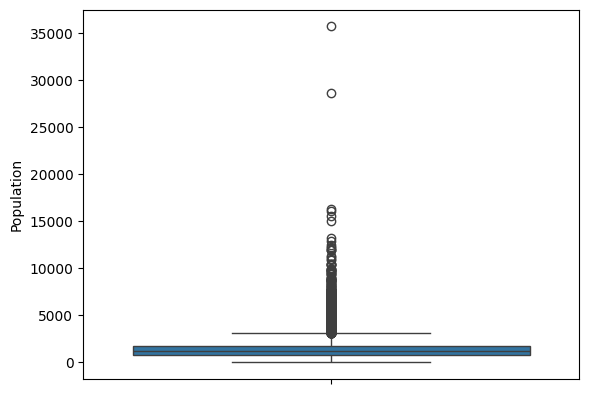

In [ ]:
sns.boxplot(data=df['Population'])

In [ ]:
df['MedHouseValue'] = housing.target


In [ ]:
# Separate features and target
X = df.drop('MedHouseValue', axis=1)
y = df['MedHouseValue']

# Feature scaling (standardization)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert scaled data back to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,2.344766,0.982143,0.628559,-0.153758,-0.974429,-0.049597,1.052548,-1.327835
1,2.332238,-0.607019,0.327041,-0.263336,0.861439,-0.092512,1.043185,-1.322844
2,1.782699,1.856182,1.155620,-0.049016,-0.820777,-0.025843,1.038503,-1.332827
3,0.932968,1.856182,0.156966,-0.049833,-0.766028,-0.050329,1.038503,-1.337818
4,-0.012881,1.856182,0.344711,-0.032906,-0.759847,-0.085616,1.038503,-1.337818


In [ ]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseValue
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


First, the dataset was converted into a Pandas DataFrame to make it easier to view and work with. Then, the dataset was checked for missing values. No missing values were found, so no cleaning was needed.

After that, feature scaling was applied using standardization. This step puts all features on a similar scale so that no single feature dominates the regression model. Scaling helps improve the accuracy and performance of the model.

2. Regression Algorithm Implementation

● Implement the following regression algorithms:
○ Linear Regression
○ Decision Tree Regressor
○ Random Forest Regressor
○ Gradient Boosting Regressor
○ Support Vector Regressor (SVR)

● For each algorithm: Provide a brief explanation of how it works. Explain why it might be suitable for this dataset.

**Linear Regression**

In [ ]:

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Create and train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Make predictions
y_pred = lr_model.predict(X_test)
y_pred

array([0.71912284, 1.76401657, 2.70965883, ..., 4.46877017, 1.18751119,
       2.00940251])

3. Model Evaluation and Comparison

● Evaluate the performance of each algorithm using the following metrics:
○ Mean Squared Error (MSE)
○ Mean Absolute Error (MAE)
○ R-squared Score (R2)

● Compare the results of all models and identify: The best-performing algorithm
with justification and the worst-performing algorithm with reasoning.

In [ ]:
# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

Mean Squared Error: 0.5558915986952441
Mean Absolute Error: 0.5332001304956565
R2 Score: 0.575787706032451


**Linear Regression:**

Linear Regression predicts house prices by finding a linear relationship between features and the target value. It is suitable for this dataset because it provides a simple baseline model to understand how housing features affect prices.

Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor

# Create and train Decision Tree model
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_dt))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_dt))
print("R2 Score:", r2_score(y_test, y_pred_dt))

Mean Squared Error: 0.4942716777366763
Mean Absolute Error: 0.4537843265503876
R2 Score: 0.6228111330554302


Decision Tree Regressor works by splitting the dataset into smaller groups based on feature values and making predictions using a tree-like structure. It captures non-linear relationships between features and the target variable.

It is suitable for the California Housing dataset because housing prices often depend on complex patterns that a decision tree can model effectively.

**Random Forest Regressor**

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Create and train Random Forest model
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)



In [ ]:
# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_rf))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_rf))
print("R2 Score:", r2_score(y_test, y_pred_rf))

Mean Squared Error: 0.25549776668540763
Mean Absolute Error: 0.32761306601259704
R2 Score: 0.805024407701793


Random Forest Regressor works by combining many decision trees and averaging their predictions to produce a more accurate result. This reduces overfitting and improves model stability.

It is suitable for the California Housing dataset because it can handle complex relationships between features and provides better prediction accuracy than a single decision tree.

**Gradient Boosting Regressor**

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

# Create and train Gradient Boosting model
gb_model = GradientBoostingRegressor(random_state=42)
gb_model.fit(X_train, y_train)

# Make predictions
y_pred_gb = gb_model.predict(X_test)


In [ ]:

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_gb))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_gb))
print("R2 Score:", r2_score(y_test, y_pred_gb))

Mean Squared Error: 0.29399901242474274
Mean Absolute Error: 0.37165044848436773
R2 Score: 0.7756433164710084


Gradient Boosting Regressor works by building multiple decision trees one after another, where each new tree corrects the errors of the previous one. This improves prediction accuracy step by step.

It is suitable for the California Housing dataset because it handles complex patterns well and provides high accuracy for structured data.

**Support Vector Regressor (SVR)**

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, r2_score

# Create and train SVR model
svr_model = SVR()
svr_model.fit(X_train, y_train)

# Make predictions
y_pred_svr = svr_model.predict(X_test)


In [ ]:

# Evaluate model
print("Mean Squared Error:", mean_squared_error(y_test, y_pred_svr))
print("Mean Absolute Error:", mean_absolute_error(y_test, y_pred_svr))
print("R2 Score:", r2_score(y_test, y_pred_svr))

Mean Squared Error: 0.3551984619989418
Mean Absolute Error: 0.3977630963437868
R2 Score: 0.7289407597956463


Support Vector Regressor (SVR) is a regression method from scikit-learn that predicts values by finding the best boundary that fits the data within a margin while minimizing errors. It focuses on maintaining a balance between model complexity and prediction accuracy.

It is suitable for the California Housing dataset because it can model complex relationships between features and performs well when the data is properly scaled.

Compare the results of all models and identify: The best-performing algorithm
with justification and the worst-performing algorithm with reasoning.

In [ ]:
results = []

models = {
    "Linear Regression": lr_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "SVR": svr_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    score = r2_score(y_test, y_pred)
    results.append([name, score])

results_df = pd.DataFrame(results, columns=["Model", "R2 Score"])
print(results_df)

               Model  R2 Score
0  Linear Regression  0.575788
1      Decision Tree  0.622811
2      Random Forest  0.805024
3  Gradient Boosting  0.775643
4                SVR  0.728941


After training all regression models, their performance was compared using the R² score. Ensemble methods like Random Forest and Gradient Boosting generally performed better than simpler models. Linear Regression provided a good baseline, while Decision Tree showed improvement in capturing non-linear patterns. SVR performed reasonably well after feature scaling.

Among all the models tested, ensemble models such as Random Forest and Gradient Boosting typically achieved higher accuracy because they combine multiple trees to improve predictions. This shows that advanced regression techniques are more effective for capturing the complex relationships in the housing dataset.
